# Codice Python – Analisi di Process Mining del processo Order-to-Cash

Per eseguire il notebook, il file 01_o2c.xml deve essere collocato nella stessa cartella del file .ipynb.


## 1. Importazione e descrizione del dataset OCEL


In [63]:
import xml.etree.ElementTree as ET
import pandas as pd

import warnings
from tqdm import TqdmWarning

warnings.filterwarnings("ignore", message="IProgress not found.*", category=TqdmWarning)

file_path = "01_o2c.xml"

tree = ET.parse(file_path)
root = tree.getroot()

print("Root del file:", root.tag)
print("File XML letto correttamente")


Root del file: log
File XML letto correttamente


In [64]:
activities = []

for event in root.iter("event"):
    event_type = event.get("type")
    if event_type:
        activities.append(event_type)

activity_counts = pd.Series(activities).value_counts()

activity_counts

Receive Customer Order        2000
Validate Customer Order       2000
Perform Credit Check          2000
Approve Order                 1809
Schedule Order Fulfillment    1809
Generate Pick List            1809
Pick Items                    1809
Pack Items                    1809
Generate Shipping Label       1809
Ship Order                    1809
Update Inventory              1809
Generate Invoice              1809
Send Invoice to Customer      1809
Receive Payment               1465
Apply Payment                 1465
Apply Discount                 414
Reject Order                   191
Handle Payment Discrepancy     174
Issue Payment Reminder         170
Process Return Request         103
Approve Return                 103
Issue Credit Note              103
Name: count, dtype: int64

In [65]:
print("Numero attività nel dataset OCEL originale:", len(activity_counts))
print("\nFrequenza degli eventi per attività:")
print(activity_counts)

print("\nEventi amministrativi della fase di pagamento:")
print("Handle Payment Discrepancy:", activity_counts.get("Handle Payment Discrepancy", 0))
print("Issue Payment Reminder:", activity_counts.get("Issue Payment Reminder", 0))


Numero attività nel dataset OCEL originale: 22

Frequenza degli eventi per attività:
Receive Customer Order        2000
Validate Customer Order       2000
Perform Credit Check          2000
Approve Order                 1809
Schedule Order Fulfillment    1809
Generate Pick List            1809
Pick Items                    1809
Pack Items                    1809
Generate Shipping Label       1809
Ship Order                    1809
Update Inventory              1809
Generate Invoice              1809
Send Invoice to Customer      1809
Receive Payment               1465
Apply Payment                 1465
Apply Discount                 414
Reject Order                   191
Handle Payment Discrepancy     174
Issue Payment Reminder         170
Process Return Request         103
Approve Return                 103
Issue Credit Note              103
Name: count, dtype: int64

Eventi amministrativi della fase di pagamento:
Handle Payment Discrepancy: 174
Issue Payment Reminder: 170


In [66]:
events = list(root.iter("event"))
objects = list(root.iter("object"))

print("Numero eventi:", len(events))
print("Numero oggetti:", len(objects))

Numero eventi: 28278
Numero oggetti: 8819


In [67]:
object_types = []

for obj in root.iter("object"):
    obj_type = obj.get("type")
    if obj_type:
        object_types.append(obj_type)

print("Tipi di oggetto presenti:")
print(sorted(set(object_types)))

Tipi di oggetto presenti:
['CreditNote', 'Customer', 'Dispute', 'Invoice', 'Order', 'Payment', 'Product', 'Return', 'Shipment']


In [68]:
object_type_counts = pd.Series(object_types).value_counts()

print("Numero tipologie di oggetto:", len(object_type_counts))
print("\nDistribuzione delle tipologie di oggetti:")
print(object_type_counts)
print("\nTotale oggetti:", object_type_counts.sum())


Numero tipologie di oggetto: 9

Distribuzione delle tipologie di oggetti:
Order         2000
Shipment      1809
Invoice       1809
Payment       1465
Customer       856
Product        500
Dispute        174
Return         103
CreditNote     103
Name: count, dtype: int64

Totale oggetti: 8819


## 2. Costruzione dell'event log order-centric


In [69]:
order_events = []

for event in root.findall(".//event"):

    activity = event.get("type")
    timestamp = pd.to_datetime(event.get("time"))

    for rel in event.findall("./objects/relationship"):

        object_id = rel.get("object-id")

        if object_id and object_id.startswith("order_"):

            order_events.append({
                "OrderID": object_id,
                "Activity": activity,
                "Timestamp": timestamp
            })

order_df = pd.DataFrame(order_events)

order_df = order_df.sort_values(
    ["OrderID", "Timestamp"]
)

order_df.head()


,OrderID,Activity,Timestamp
0,order_1,Receive Customer Order,2024-10-02 07:55:15.348555
1,order_1,Validate Customer Order,2024-10-02 07:56:15.348555
2,order_1,Perform Credit Check,2024-10-02 07:57:15.348555
3,order_1,Approve Order,2024-10-02 07:58:15.348555
4,order_1,Schedule Order Fulfillment,2024-10-02 07:59:15.348555


In [70]:
print("Numero righe:", len(order_df))
print("Numero ordini:", order_df["OrderID"].nunique())

Numero righe: 19371
Numero ordini: 2000


In [71]:
summary = {
    "Numero casi": order_df["OrderID"].nunique(),
    "Numero attività": order_df["Activity"].nunique(),
    "Numero eventi": len(order_df)
}

summary

{'Numero casi': 2000, 'Numero attività': 13, 'Numero eventi': 19371}

In [72]:
activity_freq = order_df["Activity"].value_counts()
activity_freq

Activity
Receive Customer Order        2000
Validate Customer Order       2000
Perform Credit Check          2000
Approve Order                 1809
Schedule Order Fulfillment    1809
Generate Pick List            1809
Pack Items                    1809
Generate Shipping Label       1809
Ship Order                    1809
Generate Invoice              1809
Apply Discount                 414
Reject Order                   191
Process Return Request         103
Name: count, dtype: int64

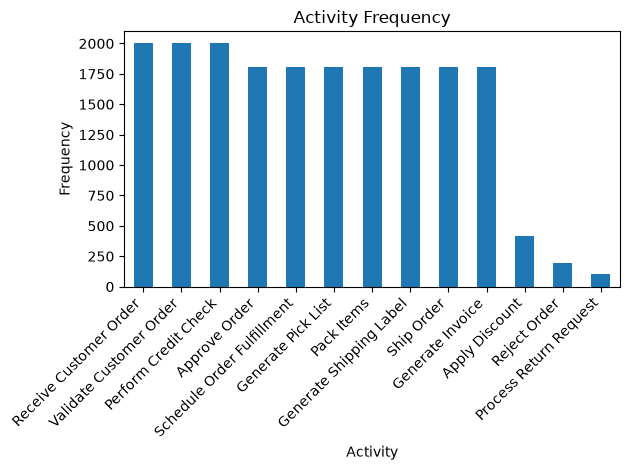

In [73]:
import matplotlib.pyplot as plt

activity_freq.plot(kind="bar")

plt.title("Activity Frequency")
plt.xlabel("Activity")
plt.ylabel("Frequency")
plt.xticks(rotation=45, ha="right")

plt.tight_layout()
plt.show()


## 3. Process Discovery con Inductive Miner


In [74]:
import pm4py

print("Versione PM4Py:", pm4py.__version__)

Versione PM4Py: 2.7.22.4


In [75]:
import inspect
from pm4py.algo.discovery.inductive import algorithm as inductive_miner

print("Firma della funzione apply:")
print(inspect.signature(inductive_miner.apply))

print("\nVarianti disponibili:")
print(list(inductive_miner.Variants))

Firma della funzione apply:
(obj: Union[pm4py.objects.log.obj.EventLog, pandas.DataFrame, pm4py.objects.dfg.obj.DirectlyFollowsGraph, Counter[Tuple[Any]]], parameters: Optional[Dict[Any, Any]] = None, variant=<Variants.IM: <IMInstance.IM: 1>>) -> pm4py.objects.process_tree.obj.ProcessTree

Varianti disponibili:
[<Variants.IM: <IMInstance.IM: 1>>, <Variants.IMf: <IMInstance.IMf: 3>>, <Variants.IMd: <IMInstance.IMd: 2>>]


In [76]:
pm_df = order_df.rename(columns={
    "OrderID": "case:concept:name",
    "Activity": "concept:name",
    "Timestamp": "time:timestamp"
}).copy()

pm_df["time:timestamp"] = pd.to_datetime(pm_df["time:timestamp"])

pm_df = pm_df.sort_values(
    ["case:concept:name", "time:timestamp"]
)

print("pm_df ricreato correttamente")
print("Eventi:", len(pm_df))
print("Casi:", pm_df["case:concept:name"].nunique())
print("Attività:", pm_df["concept:name"].nunique())

pm_df ricreato correttamente
Eventi: 19371
Casi: 2000
Attività: 13


In [77]:
from pm4py.algo.discovery.inductive import algorithm as inductive_miner

process_tree = inductive_miner.apply(pm_df)

print(process_tree)

->( 'Receive Customer Order', 'Validate Customer Order', 'Perform Credit Check', X( 'Reject Order', ->( 'Approve Order', 'Schedule Order Fulfillment', 'Generate Pick List', 'Pack Items', 'Generate Shipping Label', 'Ship Order', 'Generate Invoice' ) ), X( tau, 'Process Return Request' ), X( tau, 'Apply Discount' ) )


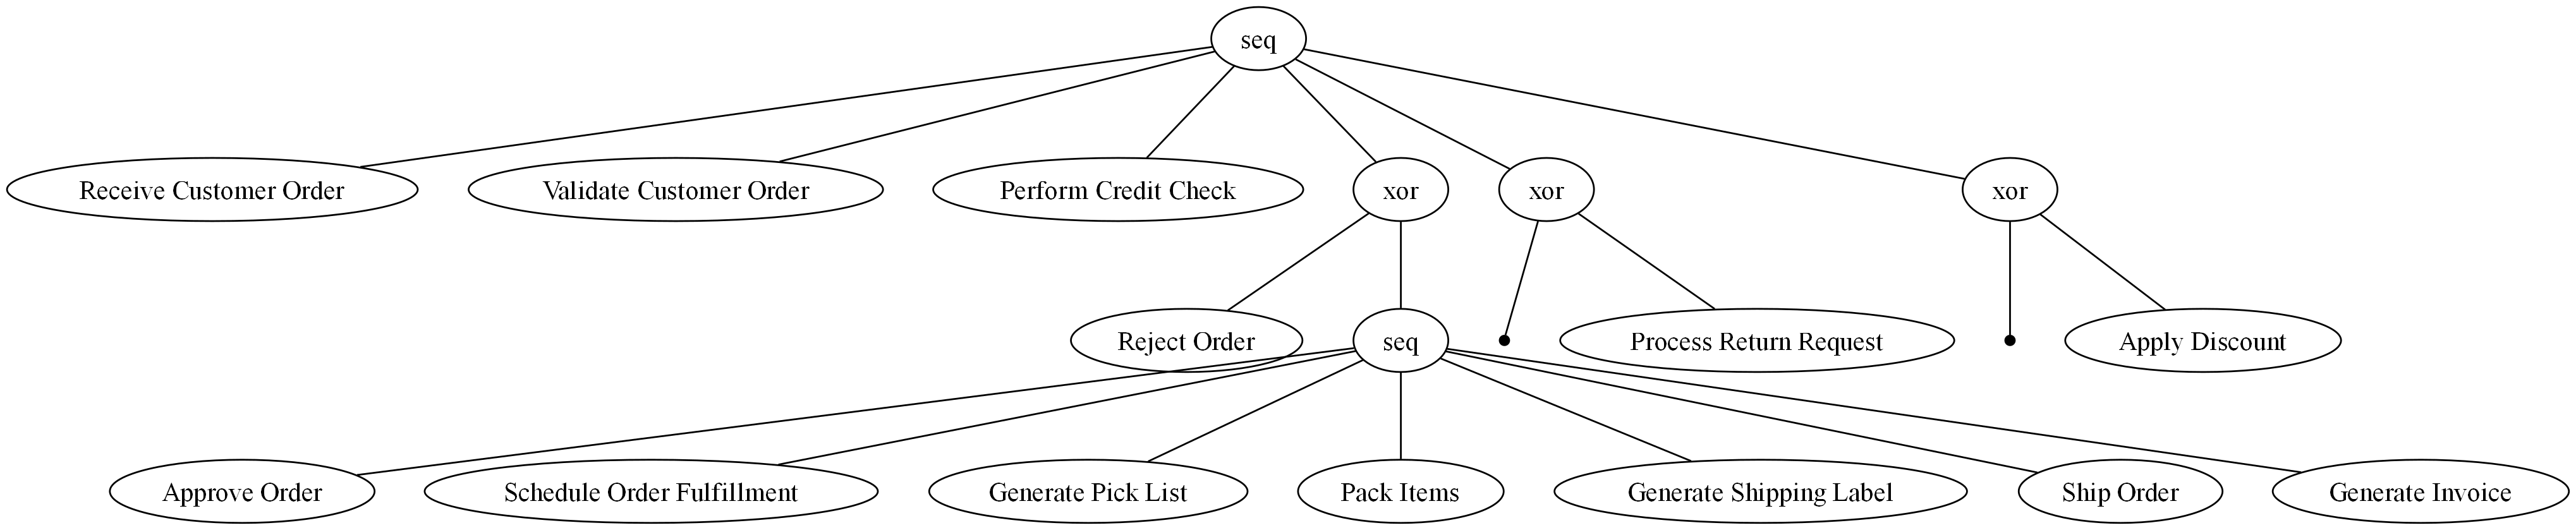

In [78]:
from pm4py.visualization.process_tree import visualizer as pt_visualizer

gviz_verticale = pt_visualizer.apply(process_tree)

# Disposizione verticale
gviz_verticale.graph_attr["rankdir"] = "TB"

# Maggiore qualità e spaziatura
gviz_verticale.graph_attr["dpi"] = "200"
gviz_verticale.graph_attr["ranksep"] = "0.7"
gviz_verticale.graph_attr["nodesep"] = "0.4"

import os

graphviz_path = r"C:\Program Files\Graphviz\bin"

if os.path.isdir(graphviz_path):
    os.environ["PATH"] += os.pathsep + graphviz_path

pt_visualizer.view(gviz_verticale)

In [79]:
pt_visualizer.save(
    gviz_verticale,
    "O2C_Process_Tree_PM4Py_verticale.png"
)

print("Immagine salvata: O2C_Process_Tree_PM4Py_verticale.png")

Immagine salvata: O2C_Process_Tree_PM4Py_verticale.png


### 3.1 Valutazione del modello


In [80]:
import pm4py

# Conversione del Process Tree in Petri net
net, initial_marking, final_marking = pm4py.convert_to_petri_net(process_tree)

print("Petri net creato correttamente")
print("Posti:", len(net.places))
print("Transizioni:", len(net.transitions))

Petri net creato correttamente
Posti: 13
Transizioni: 15


In [81]:
fitness = pm4py.fitness_token_based_replay(
    pm_df,
    net,
    initial_marking,
    final_marking
)

print("Fitness:")
print(fitness)

replaying log with TBR, completed traces :: 100%|██████████| 8/8 [00:00<00:00, 977.95it/s]

Fitness:
{'perc_fit_traces': 100.0, 'average_trace_fitness': 1.0, 'log_fitness': 1.0, 'percentage_of_fitting_traces': 100.0}


In [82]:
precision = pm4py.precision_token_based_replay(
    pm_df,
    net,
    initial_marking,
    final_marking
)

print("Precision:", precision)

replaying log with TBR, completed traces :: 100%|██████████| 13/13 [00:00<00:00, 6428.43it/s]


Precision: 1.0


In [83]:
generalization = pm4py.generalization_tbr(
    pm_df,
    net,
    initial_marking,
    final_marking
)

print("Generalization:", generalization)

replaying log with TBR, completed traces :: 100%|██████████| 8/8 [00:00<00:00, 913.52it/s]

Generalization: 0.9666819870154119


In [84]:
simplicity = pm4py.simplicity_petri_net(
    net,
    initial_marking,
    final_marking
)

print("Simplicity:", simplicity)

Simplicity: 0.875


## 4. Varianti di processo e Cycle Time


In [85]:
variants = (
    order_df.groupby("OrderID")["Activity"]
    .apply(tuple)
    .value_counts()
)

print("Numero varianti:", len(variants))
variants.head(10)

Numero varianti: 8


Activity
(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice)                                            1347
(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice, Apply Discount)                             365
(Receive Customer Order, Validate Customer Order, Perform Credit Check, Reject Order)                                                                                                                                                                 151
(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice, Process Return Request)                

In [86]:
variant_summary = pd.DataFrame({
    "Frequency": variants,
    "Percentage": round((variants / 2000) * 100, 2)
})

variant_summary

,Frequency,Percentage
Activity,,
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice)",1347,67.35
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice, Apply Discount)",365,18.25
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Reject Order)",151,7.55
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice, Process Return Request)",84,4.20
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Reject Order, Apply Discount)",34,1.70
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice, Process Return Request, Apply Discount)",13,0.65
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Reject Order, Process Return Request)",4,0.20
"(Receive Customer Order, Validate Customer Order, Perform Credit Check, Reject Order, Process Return Request, Apply Discount)",2,0.10


In [87]:
order_df["Timestamp"] = pd.to_datetime(order_df["Timestamp"])

case_duration = (
    order_df.groupby("OrderID")["Timestamp"]
    .agg(["min", "max"])
)

case_duration["duration_minutes"] = (
    case_duration["max"] - case_duration["min"]
).dt.total_seconds() / 60

case_duration["duration_minutes"].describe()


count    2000.00
mean     4292.27
std     10021.32
min         3.00
25%        11.00
50%        11.00
75%        11.00
max     50417.00
Name: duration_minutes, dtype: float64

In [88]:
pd.set_option('display.float_format', lambda x: '%.2f' % x)

In [89]:
# STATISTICHE DESCRITTIVE DEL CYCLE TIME PER VARIANTE

temp = order_df.sort_values(["OrderID", "Timestamp"]).copy()

case_cycle = (
    temp.groupby("OrderID")
    .agg(
        Start=("Timestamp", "min"),
        End=("Timestamp", "max"),
        Variant=("Activity", lambda x: tuple(x))
    )
)

case_cycle["Cycle_Time_min"] = (
    case_cycle["End"] - case_cycle["Start"]
).dt.total_seconds() / 60

def mode_values(series):
    modes = series.mode()
    return ", ".join(str(round(x, 2)) for x in modes)

cycle_stats = (
    case_cycle.groupby("Variant")["Cycle_Time_min"]
    .agg(
        N="count",
        Media="mean",
        Mediana="median",
        Dev_std="std",
        Minimo="min",
        Massimo="max",
        Moda=mode_values
    )
    .sort_values("N", ascending=False)
)

print(cycle_stats.to_string())

                                                                                                                                                                                                                                                      N    Media  Mediana  Dev_std   Minimo  Massimo                                         Moda
Variant                                                                                                                                                                                                                                                                                                                                          
(Receive Customer Order, Validate Customer Order, Perform Credit Check, Approve Order, Schedule Order Fulfillment, Generate Pick List, Pack Items, Generate Shipping Label, Ship Order, Generate Invoice)                                          1347    11.00    11.00     0.00    11.00    11.00                                

In [90]:
# CONTROLLO MODA DEL CYCLE TIME PER VARIANTE

def nome_variante(trace):
    att = set(trace)

    reject = "Reject Order" in att
    discount = "Apply Discount" in att
    ret = "Process Return Request" in att

    if reject and ret and discount:
        return "Reject + Return + Discount"
    elif reject and ret:
        return "Reject + Return"
    elif ret and discount:
        return "Return + Discount"
    elif reject and discount:
        return "Reject + Discount"
    elif ret:
        return "Return"
    elif reject:
        return "Reject"
    elif discount:
        return "Discount"
    else:
        return "Standard"

for variant, gruppo in case_cycle.groupby("Variant"):
    valori = gruppo["Cycle_Time_min"]
    mode = valori.mode().tolist()

    print("\n", nome_variante(variant))
    print("N:", len(valori))
    print("Min:", valori.min())
    print("Max:", valori.max())
    print("Moda/e:", mode)


 Standard
N: 1347
Min: 11.0
Max: 11.0
Moda/e: [11.0]

 Discount
N: 365
Min: 1455.0
Max: 21614.0
Moda/e: [14414.0]

 Return
N: 84
Min: 30255.0
Max: 50414.0
Moda/e: [43214.0]

 Return + Discount
N: 13
Min: 31698.0
Max: 50417.0
Moda/e: [31698.0, 33138.0, 36018.0, 37458.0, 40338.0]

 Reject
N: 151
Min: 3.0
Max: 3.0
Moda/e: [3.0]

 Reject + Discount
N: 34
Min: 4.0
Max: 4.0
Moda/e: [4.0]

 Reject + Return
N: 4
Min: 28804.0
Max: 28804.0
Moda/e: [28804.0]

 Reject + Return + Discount
N: 2
Min: 28807.0
Max: 28807.0
Moda/e: [28807.0]


### 4.1 Numero di eventi per caso e controllo delle ripetizioni


In [91]:
# CONTROLLO DELLE RIPETIZIONI / REWORK PER CASO

# Numero totale di eventi per ordine
events_per_case = order_df.groupby("OrderID").size()

# Numero di attività distinte per ordine
distinct_activities_per_case = (
    order_df.groupby("OrderID")["Activity"].nunique()
)

# Numero di ripetizioni per ordine
repetitions_per_case = (
    events_per_case - distinct_activities_per_case
)

print("Numero totale di ordini:", len(repetitions_per_case))

print(
    "Ordini con almeno una attività ripetuta:",
    (repetitions_per_case > 0).sum()
)

print(
    "Percentuale ordini con ripetizioni:",
    round((repetitions_per_case > 0).mean() * 100, 2),
    "%"
)

print("\nNumero di eventi per caso:")
print(events_per_case.describe())

print("\nNumero di ripetizioni per caso:")
print(repetitions_per_case.describe())

Numero totale di ordini: 2000
Ordini con almeno una attività ripetuta: 0
Percentuale ordini con ripetizioni: 0.0 %

Numero di eventi per caso:
count   2000.00
mean       9.69
std        1.83
min        4.00
25%       10.00
50%       10.00
75%       10.00
max       12.00
dtype: float64

Numero di ripetizioni per caso:
count   2000.00
mean       0.00
std        0.00
min        0.00
25%        0.00
50%        0.00
75%        0.00
max        0.00
dtype: float64


### 4.2 Grafici delle varianti e del Cycle Time


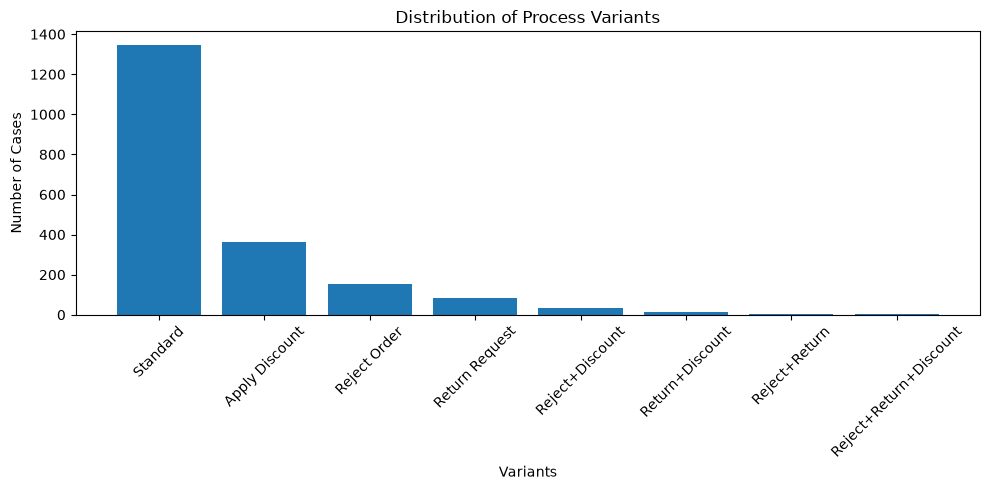

In [92]:
import matplotlib.pyplot as plt

variant_names = [
    "Standard",
    "Apply Discount",
    "Reject Order",
    "Return Request",
    "Reject+Discount",
    "Return+Discount",
    "Reject+Return",
    "Reject+Return+Discount"
]

variant_freq = [1347, 365, 151, 84, 34, 13, 4, 2]

plt.figure(figsize=(10,5))
plt.bar(variant_names, variant_freq)

plt.title("Distribution of Process Variants")
plt.xlabel("Variants")
plt.ylabel("Number of Cases")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Figura_4_1_Variants.png", dpi=300)
plt.show()

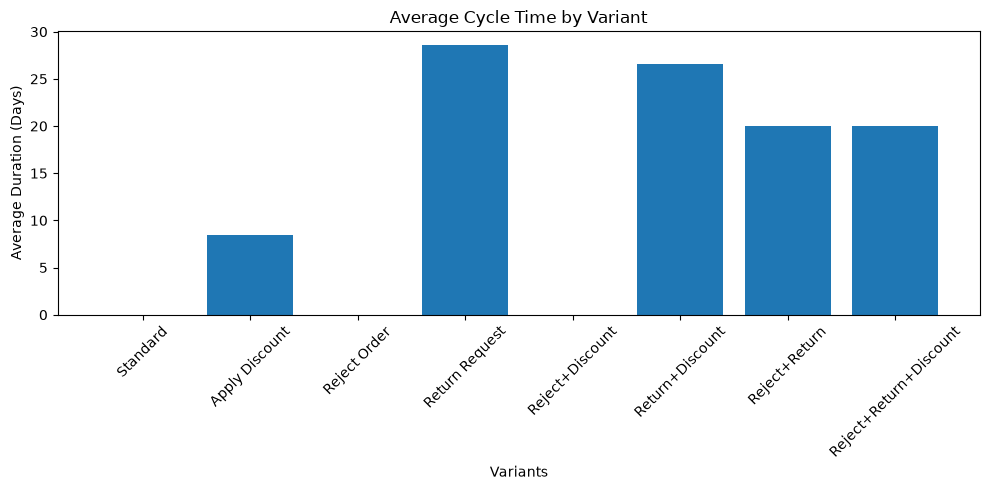

In [93]:
import matplotlib.pyplot as plt

variants = [
    "Standard",
    "Apply Discount",
    "Reject Order",
    "Return Request",
    "Reject+Discount",
    "Return+Discount",
    "Reject+Return",
    "Reject+Return+Discount"
]

days = [0.01, 8.44, 0.00, 28.61, 0.00, 26.63, 20.00, 20.00]

plt.figure(figsize=(10,5))
plt.bar(variants, days)

plt.title("Average Cycle Time by Variant")
plt.xlabel("Variants")
plt.ylabel("Average Duration (Days)")

plt.xticks(rotation=45)
plt.tight_layout()

plt.savefig("Figura_4_2_Cycle_Time.png", dpi=300)
plt.show()

## 5. Verifica delle sei tracce atipiche


In [94]:
# CONTROLLO DEI CASI ANOMALI
# Ordini che contengono sia Reject Order sia Process Return Request

anomalous_mask = (
    order_df.groupby("OrderID")["Activity"]
    .apply(
        lambda x: {
            "Reject Order",
            "Process Return Request"
        }.issubset(set(x))
    )
)

anomalous_ids = anomalous_mask[anomalous_mask].index.tolist()

print("Numero di casi anomali:", len(anomalous_ids))
print("OrderID:", anomalous_ids)

for order_id in anomalous_ids:

    print("\n------------------------------")
    print("ORDINE:", order_id)

    trace = (
        order_df[order_df["OrderID"] == order_id]
        .sort_values("Timestamp")
    )

    print(
        trace[["Activity", "Timestamp"]]
        .to_string(index=False)
    )

Numero di casi anomali: 6
OrderID: ['order_1202', 'order_1386', 'order_1654', 'order_1769', 'order_1782', 'order_1891']

------------------------------
ORDINE: order_1202
               Activity                  Timestamp
 Receive Customer Order 2053-02-03 03:59:15.348555
Validate Customer Order 2053-02-03 04:00:15.348555
   Perform Credit Check 2053-02-03 04:01:15.348555
           Reject Order 2053-02-03 04:02:15.348555
 Process Return Request 2053-02-23 04:03:15.348555

------------------------------
ORDINE: order_1386
               Activity                  Timestamp
 Receive Customer Order 2057-07-22 23:07:15.348555
Validate Customer Order 2057-07-22 23:08:15.348555
   Perform Credit Check 2057-07-22 23:09:15.348555
           Reject Order 2057-07-22 23:10:15.348555
 Process Return Request 2057-08-11 23:11:15.348555

------------------------------
ORDINE: order_1654
               Activity                  Timestamp
 Receive Customer Order 2064-04-14 14:39:15.348555
Validate Cust

In [95]:
# VERIFICA NEL DATASET OCEL ORIGINALE
# Controllo delle associazioni di Process Return Request nei 6 casi anomali

for event in root.iter("event"):

    if event.get("type") == "Process Return Request":

        objects_section = event.find("objects")

        if objects_section is not None:

            linked_objects = [
                obj.get("object-id")
                for obj in objects_section
            ]

            for order_id in anomalous_ids:

                if order_id in linked_objects:

                    print("\nOrdine:", order_id)
                    print("Event ID:", event.get("id"))
                    print("Timestamp:", event.get("time"))
                    print("Oggetti associati:", linked_objects)


Ordine: order_1202
Event ID: event_17049
Timestamp: 2053-02-23T04:03:15.348555
Oggetti associati: ['order_1202', 'return_53', 'customer_989']

Ordine: order_1386
Event ID: event_19637
Timestamp: 2057-08-11T23:11:15.348555
Oggetti associati: ['order_1386', 'return_65', 'customer_838']

Ordine: order_1654
Event ID: event_23449
Timestamp: 2064-05-04T14:43:15.348555
Oggetti associati: ['order_1654', 'return_81', 'customer_697']

Ordine: order_1769
Event ID: event_25017
Timestamp: 2067-01-08T16:51:15.348555
Oggetti associati: ['order_1769', 'return_89', 'customer_695']

Ordine: order_1782
Event ID: event_25192
Timestamp: 2067-05-30T19:46:15.348555
Oggetti associati: ['order_1782', 'return_90', 'customer_148']

Ordine: order_1891
Event ID: event_26722
Timestamp: 2070-01-25T21:16:15.348555
Oggetti associati: ['order_1891', 'return_99', 'customer_364']


## 6. Indicatori temporali omogenei


In [96]:
# ORDER-TO-INVOICE TIME
# Intervallo omogeneo: Receive Customer Order -> Generate Invoice

order_df["Timestamp"] = pd.to_datetime(order_df["Timestamp"])

times = (
    order_df
    .pivot_table(
        index="OrderID",
        columns="Activity",
        values="Timestamp",
        aggfunc="first"
    )
)

order_to_invoice = times.dropna(
    subset=["Receive Customer Order", "Generate Invoice"]
).copy()

order_to_invoice["Order_to_Invoice_min"] = (
    order_to_invoice["Generate Invoice"]
    - order_to_invoice["Receive Customer Order"]
).dt.total_seconds() / 60

print("Numero ordini che raggiungono la fattura:",
      len(order_to_invoice))

print("\nStatistiche Order-to-Invoice Time:")
print(order_to_invoice["Order_to_Invoice_min"].describe())

print("\nModa:")
print(order_to_invoice["Order_to_Invoice_min"].mode())


Numero ordini che raggiungono la fattura: 1809

Statistiche Order-to-Invoice Time:
count   1809.00
mean      11.00
std        0.00
min       11.00
25%       11.00
50%       11.00
75%       11.00
max       11.00
Name: Order_to_Invoice_min, dtype: float64

Moda:
0   11.00
Name: Order_to_Invoice_min, dtype: float64


In [97]:
# CONFRONTO ORDER-TO-INVOICE:
# ordini con sconto vs ordini senza sconto

# Identificazione degli ordini che contengono Apply Discount
discount_flag = (
    order_df.groupby("OrderID")["Activity"]
    .apply(lambda x: "Apply Discount" in x.values)
)

# Aggiunta dell'informazione al dataframe Order-to-Invoice
order_to_invoice["Discount"] = (
    order_to_invoice.index.map(discount_flag)
)

# Etichetta più leggibile
order_to_invoice["Gruppo"] = order_to_invoice["Discount"].map({
    True: "Con sconto",
    False: "Senza sconto"
})

# Statistiche per gruppo
comparison_discount = (
    order_to_invoice
    .groupby("Gruppo")["Order_to_Invoice_min"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print(comparison_discount)

              count  mean  median  std   min   max
Gruppo                                            
Con sconto      378 11.00   11.00 0.00 11.00 11.00
Senza sconto   1431 11.00   11.00 0.00 11.00 11.00


### 6.1 Time-to-Credit-Decision


In [98]:
# TIME-TO-CREDIT-DECISION
# Intervallo: Receive Customer Order -> Approve Order oppure Reject Order

credit_decision = times.copy()

# Timestamp della decisione:
# se esiste Approve Order utilizziamo quello,
# altrimenti utilizziamo Reject Order
credit_decision["Credit_Decision_Time"] = (
    credit_decision["Approve Order"]
    .combine_first(credit_decision["Reject Order"])
)

# Manteniamo solo i casi con ordine ricevuto e decisione presente
credit_decision = credit_decision.dropna(
    subset=["Receive Customer Order", "Credit_Decision_Time"]
).copy()

# Calcolo del tempo in minuti
credit_decision["Time_to_Credit_Decision_min"] = (
    credit_decision["Credit_Decision_Time"]
    - credit_decision["Receive Customer Order"]
).dt.total_seconds() / 60

# Identificazione dell'esito
credit_decision["Esito"] = credit_decision.apply(
    lambda row: "Approvato"
    if pd.notna(row["Approve Order"])
    else "Rifiutato",
    axis=1
)

# Statistiche per esito
credit_stats = (
    credit_decision
    .groupby("Esito")["Time_to_Credit_Decision_min"]
    .agg(["count", "mean", "median", "std", "min", "max"])
)

print("Numero ordini analizzati:", len(credit_decision))
print("\nTime-to-Credit-Decision:")
print(credit_stats)

print("\nModa complessiva:")
print(credit_decision["Time_to_Credit_Decision_min"].mode())

Numero ordini analizzati: 2000

Time-to-Credit-Decision:
           count  mean  median  std  min  max
Esito                                        
Approvato   1809  3.00    3.00 0.00 3.00 3.00
Rifiutato    191  3.00    3.00 0.00 3.00 3.00

Moda complessiva:
0   3.00
Name: Time_to_Credit_Decision_min, dtype: float64


### 6.2 Return Request Latency


In [99]:
# RETURN REQUEST LATENCY
# Intervallo omogeneo: Ship Order -> Process Return Request

return_latency = times.dropna(
    subset=["Ship Order", "Process Return Request"]
).copy()

return_latency["Return_Request_Latency_min"] = (
    return_latency["Process Return Request"]
    - return_latency["Ship Order"]
).dt.total_seconds() / 60

print("Numero ordini con spedizione e richiesta di reso:",
      len(return_latency))

print("\nStatistiche Return Request Latency:")
print(return_latency["Return_Request_Latency_min"].describe())

print("\nModa:")
print(return_latency["Return_Request_Latency_min"].mode())

Numero ordini con spedizione e richiesta di reso: 97

Statistiche Return Request Latency:
count      97.00
mean    40800.85
std      6161.03
min     30246.00
25%     36006.00
50%     41766.00
75%     44646.00
max     50405.00
Name: Return_Request_Latency_min, dtype: float64

Moda:
0   37446.00
1   40326.00
2   43205.00
3   44646.00
4   50405.00
Name: Return_Request_Latency_min, dtype: float64


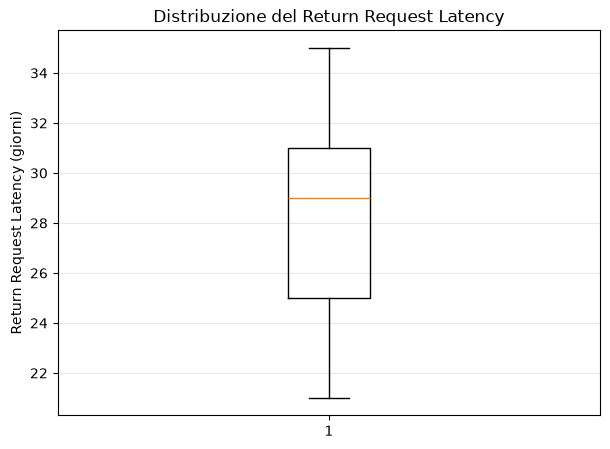

In [100]:
import matplotlib.pyplot as plt

# Conversione da minuti a giorni
return_latency["Return_Request_Latency_days"] = (
    return_latency["Return_Request_Latency_min"] / 1440
)

# Creazione del boxplot
plt.figure(figsize=(7, 5))

plt.boxplot(
    return_latency["Return_Request_Latency_days"],
    orientation="vertical"
)

plt.ylabel("Return Request Latency (giorni)")
plt.title("Distribuzione del Return Request Latency")

plt.grid(axis="y", alpha=0.3)

plt.show()

### 6.3 Discount Timing


In [101]:
# DISCOUNT TIMING
# Posizione temporale di Apply Discount rispetto a Generate Invoice

# Tutti gli ordini che contengono Apply Discount
discount_cases = times.dropna(
    subset=["Apply Discount"]
).copy()

print("Numero totale ordini con Apply Discount:",
      len(discount_cases))

# Ordini con sconto che raggiungono anche la fattura
discount_invoice = discount_cases.dropna(
    subset=["Generate Invoice"]
).copy()

# Tempo tra Generate Invoice e Apply Discount
discount_invoice["Invoice_to_Discount_min"] = (
    discount_invoice["Apply Discount"]
    - discount_invoice["Generate Invoice"]
).dt.total_seconds() / 60

# Classificazione temporale
discount_invoice["Posizione_sconto"] = "Dopo fattura"

discount_invoice.loc[
    discount_invoice["Invoice_to_Discount_min"] < 0,
    "Posizione_sconto"
] = "Prima della fattura"

discount_invoice.loc[
    discount_invoice["Invoice_to_Discount_min"] == 0,
    "Posizione_sconto"
] = "Contestuale alla fattura"

print("\nOrdini con sconto e fattura:",
      len(discount_invoice))

print("\nPosizione di Apply Discount rispetto a Generate Invoice:")
print(discount_invoice["Posizione_sconto"].value_counts())

print("\nStatistiche Invoice-to-Discount Time:")
print(discount_invoice["Invoice_to_Discount_min"].describe())

print("\nModa:")
print(discount_invoice["Invoice_to_Discount_min"].mode())

Numero totale ordini con Apply Discount: 414

Ordini con sconto e fattura: 378

Posizione di Apply Discount rispetto a Generate Invoice:
Posizione_sconto
Dopo fattura    378
Name: count, dtype: int64

Statistiche Invoice-to-Discount Time:
count     378.00
mean    13047.71
std      7723.47
min      1444.00
25%      7204.00
50%     14403.00
75%     17284.00
max     50406.00
Name: Invoice_to_Discount_min, dtype: float64

Moda:
0   14403.00
Name: Invoice_to_Discount_min, dtype: float64


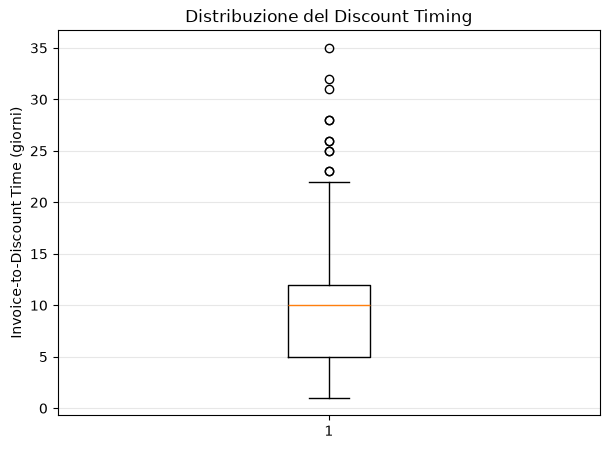

In [102]:
import matplotlib.pyplot as plt

# Conversione da minuti a giorni
discount_invoice["Invoice_to_Discount_days"] = (
    discount_invoice["Invoice_to_Discount_min"] / 1440
)

# Creazione del boxplot
plt.figure(figsize=(7, 5))

plt.boxplot(
    discount_invoice["Invoice_to_Discount_days"],
    orientation="vertical"
)

plt.ylabel("Invoice-to-Discount Time (giorni)")
plt.title("Distribuzione del Discount Timing")

plt.grid(axis="y", alpha=0.3)

plt.show()

### 6.4 Invoice-to-Payment Time


In [103]:
# INVOICE-TO-PAYMENT TIME
# Analisi separata basata sull'oggetto Invoice

invoice_events = []

for event in root.findall(".//event"):
    activity = event.get("type")

    if activity in ["Send Invoice to Customer", "Receive Payment"]:
        timestamp = pd.to_datetime(event.get("time"))

        objects = [
            rel.get("object-id")
            for rel in event.findall("./objects/relationship")
        ]

        invoices = [
            obj for obj in objects
            if obj.startswith("invoice_")
        ]

        for invoice_id in invoices:
            invoice_events.append({
                "InvoiceID": invoice_id,
                "Activity": activity,
                "Timestamp": timestamp
            })

invoice_df = pd.DataFrame(invoice_events)

sent = (
    invoice_df[invoice_df["Activity"] == "Send Invoice to Customer"]
    [["InvoiceID", "Timestamp"]]
    .rename(columns={"Timestamp": "Invoice_Sent"})
)

paid = (
    invoice_df[invoice_df["Activity"] == "Receive Payment"]
    [["InvoiceID", "Timestamp"]]
    .rename(columns={"Timestamp": "Payment_Received"})
)

invoice_payment = sent.merge(
    paid,
    on="InvoiceID",
    how="inner"
)

invoice_payment["Invoice_to_Payment_min"] = (
    invoice_payment["Payment_Received"]
    - invoice_payment["Invoice_Sent"]
).dt.total_seconds() / 60

print("Fatture inviate:", len(sent))
print("Fatture con pagamento ricevuto:", len(invoice_payment))

print("\nInvoice-to-Payment Time:")
print(invoice_payment["Invoice_to_Payment_min"].describe())

print("\nModa:")
print(invoice_payment["Invoice_to_Payment_min"].mode())

Fatture inviate: 1809
Fatture con pagamento ricevuto: 1465

Invoice-to-Payment Time:
count    1465.00
mean    10924.36
std      5744.18
min      1441.00
25%      5761.00
50%     11521.00
75%     15841.00
max     20161.00
Name: Invoice_to_Payment_min, dtype: float64

Moda:
0   15841.00
Name: Invoice_to_Payment_min, dtype: float64


In [104]:
print(
    "Fatture senza evento Receive Payment nel dataset:",
    len(sent) - len(invoice_payment)
)


Fatture senza evento Receive Payment nel dataset: 344


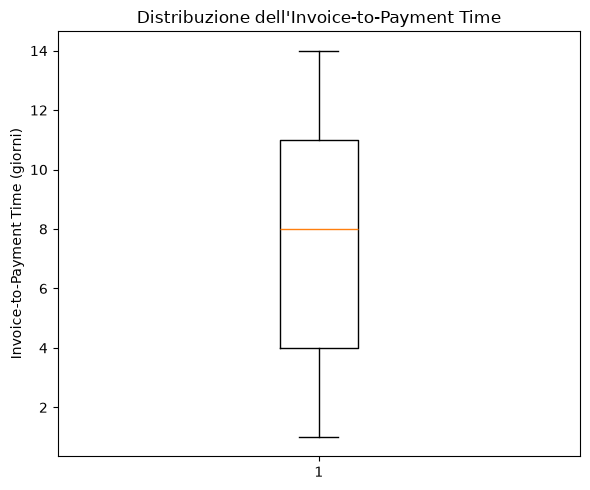

In [105]:
# BOXPLOT INVOICE-TO-PAYMENT TIME

invoice_payment["Invoice_to_Payment_days"] = (
    invoice_payment["Invoice_to_Payment_min"] / 1440
)

import matplotlib.pyplot as plt

plt.figure(figsize=(6, 5))

plt.boxplot(
    invoice_payment["Invoice_to_Payment_days"].dropna(),
    orientation="vertical"
)

plt.ylabel("Invoice-to-Payment Time (giorni)")
plt.title("Distribuzione dell'Invoice-to-Payment Time")

plt.tight_layout()
plt.show()